Model already exists.
Colorized image saved to: result_images\ansel_adams.jpg


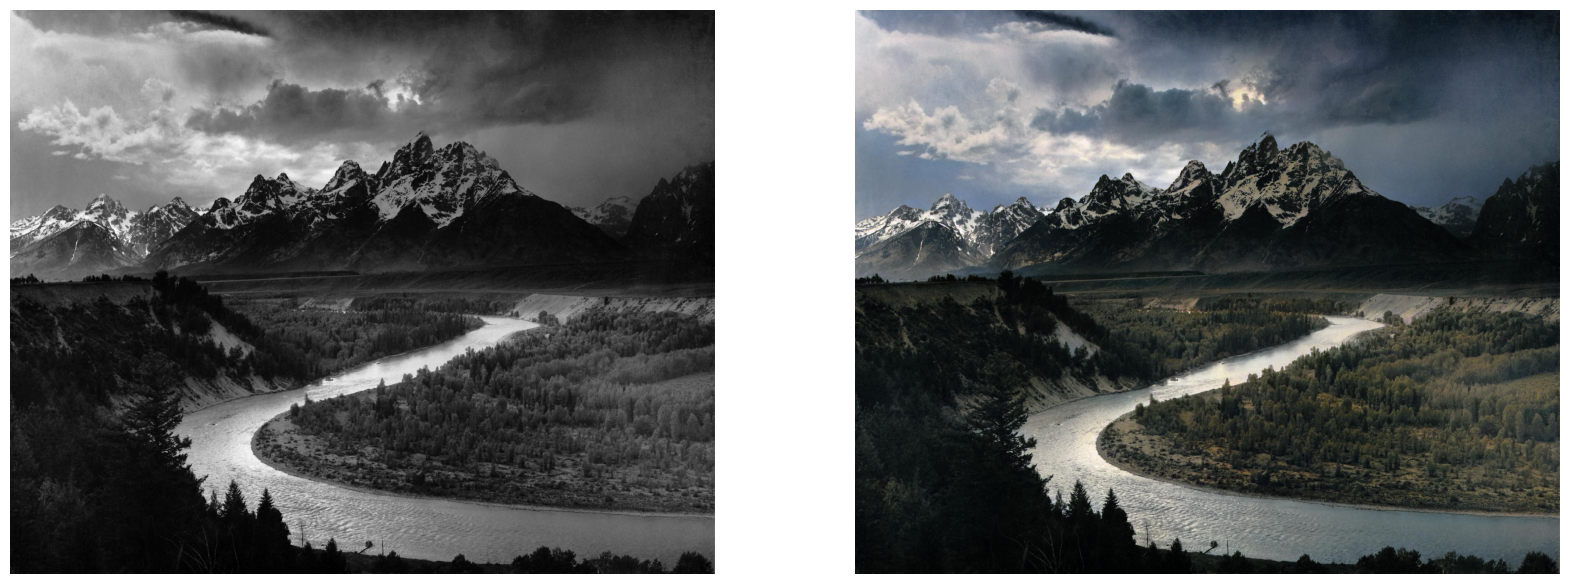

In [9]:
import os
import requests
from deoldify import device
from deoldify.device_id import DeviceId
from deoldify.visualize import *
from PIL import Image
import matplotlib.pyplot as plt
from pathlib import Path

# Step 1: Create the required directories
os.makedirs("dummy", exist_ok=True)
os.makedirs("models", exist_ok=True)
os.makedirs("result_images", exist_ok=True)
os.makedirs("test_images", exist_ok=True)

# Step 2: Download the pre-trained model
model_url = "https://data.deepai.org/deoldify/ColorizeArtistic_gen.pth"
model_path = "models/ColorizeArtistic_gen.pth"

if not os.path.exists(model_path):
    print("Downloading the Artistic model...")
    response = requests.get(model_url)
    with open(model_path, "wb") as f:
        f.write(response.content)
    print("Model downloaded successfully!")
else:
    print("Model already exists.")

# Step 3: Set up the device (GPU or CPU)
device.set(device=DeviceId.GPU0)  # Use DeviceId.CPU if you don't have a GPU

# Step 4: Load the model
colorizer = get_image_colorizer(artistic=True)

# Step 5: Colorize an image
input_path = "colorization/imgs/ansel_adams.jpg"

# Ensure the input image exists
if not os.path.exists(input_path):
    raise FileNotFoundError(f"Input image not found at {input_path}")

# Convert results_dir to a Path object
results_dir = Path("result_images")

# Colorize and save the result
output_image_path = colorizer.plot_transformed_image(
    path=input_path,
    render_factor=35,  # Adjust this for better results
    compare=True,
    results_dir=results_dir,  # Pass as a Path object
)

# Print the output path for debugging
print(f"Colorized image saved to: {output_image_path}")

# Ensure the output image exists
if not os.path.exists(output_image_path):
    raise FileNotFoundError(f"Colorized image not found at {output_image_path}")

# Open and display the colorized image
colorized_image = Image.open(output_image_path)
plt.imshow(colorized_image)
plt.axis('off')
plt.show()